# Nepal Census Population Analysis
### A Python data analysis project on Nepal's population data
**Dataset:** Nepal Census Data (All Districts)
**Tools:** Python, Pandas, Matplotlib, Seaborn
**Goal:** Analyze population distribution, gender ratio, and household data across Nepal's districts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('census.csv', encoding='utf-8-sig')

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Dataset loaded!
Shape: (753, 8)

Columns: ['_id', 'District', 'Local Level Name', 'Total family number', 'Total household number', 'Total population', 'Total Male', 'Total Female']


## Step 1: Exploring the Dataset
First look at Nepal's census data structure.

In [3]:
# First 5 rows
df.head()

,_id,District,Local Level Name,Total family number,Total household number,Total population,Total Male,Total Female
0,1,Taplejung,Aathrai Tribeni Rural Municipality,2869,2735,12288,6005,6283
1,2,Taplejung,Maiwakhola Rural Municipality,2275,2178,10365,5264,5101
2,3,Taplejung,Meringden Rural Municipality,2683,2528,12040,6181,5859
3,4,Taplejung,Mikwakhola Rural Municipality,1862,1792,7991,4000,3991
4,5,Taplejung,Phaktanglung Rural Municipality,2864,2700,11925,6239,5686


In [4]:
# Clean column names - remove extra spaces
df.columns = df.columns.str.strip()

print("Cleaned Columns:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTotal Districts:", df['District'].nunique())
print("Total Local Levels:", df['Local Level Name'].nunique())

Cleaned Columns:
['_id', 'District', 'Local Level Name', 'Total family number', 'Total household number', 'Total population', 'Total Male', 'Total Female']

Missing Values:
_id                       0
District                  0
Local Level Name          0
Total family number       0
Total household number    0
Total population          0
Total Male                0
Total Female              0
dtype: int64

Total Districts: 77
Total Local Levels: 737


In [5]:
print("Population Summary:")
print(df[['Total population', 'Total Male',
          'Total Female', 'Total family number']].describe())

Population Summary:
       Total population     Total Male   Total Female  Total family number
count        753.000000     753.000000     753.000000           753.000000
mean       38612.204515   18842.814077   19769.390438          8976.723772
std        49904.377212   24891.928559   25046.362147         12986.552238
min          398.000000     170.000000     228.000000           125.000000
25%        16768.000000    8115.000000    8553.000000          4036.000000
50%        25508.000000   12248.000000   13010.000000          5896.000000
75%        44929.000000   22100.000000   23068.000000          9510.000000
max       845767.000000  431501.000000  414266.000000        231714.000000


## Step 2: Population Analysis by District
Finding the most and least populated districts in Nepal.

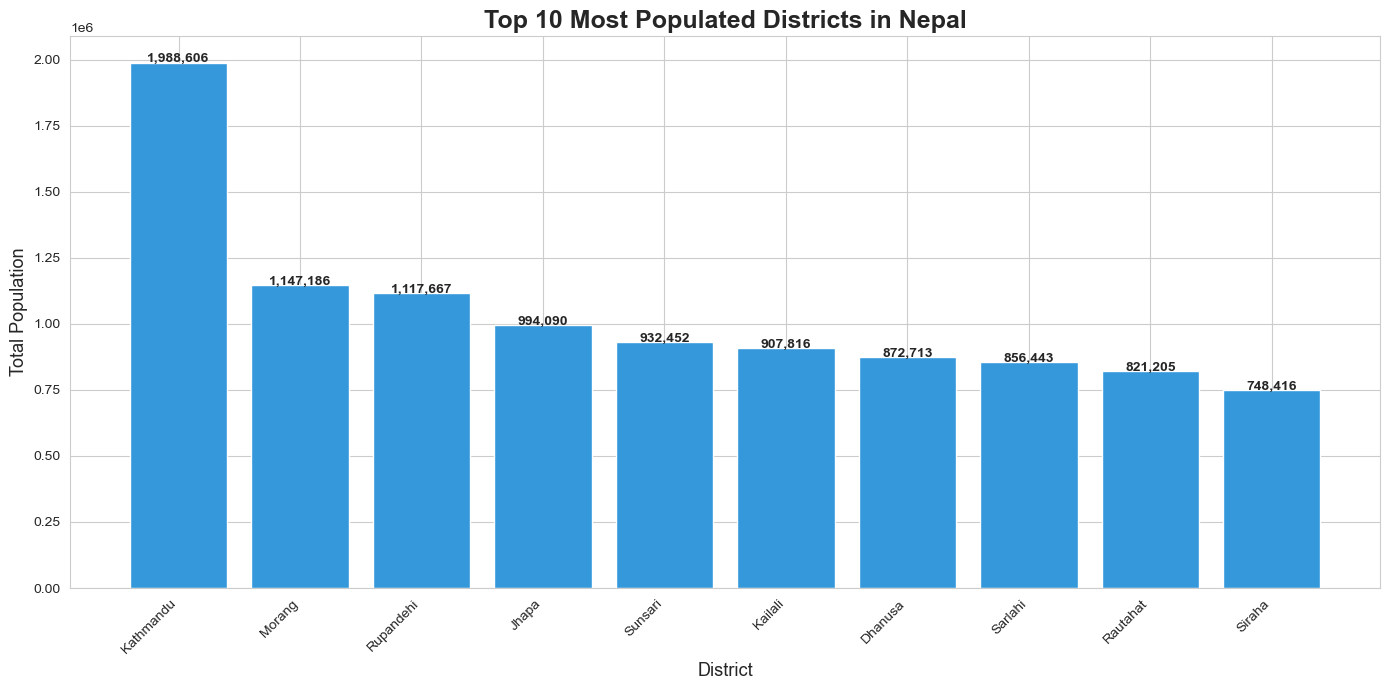

Chart 1 saved!


In [6]:
# Top 10 most populated districts
district_pop = df.groupby('District')['Total population'].sum().sort_values(ascending=False)
top10 = district_pop.head(10)

plt.figure(figsize=(14, 7))
bars = plt.bar(top10.index, top10.values, color='#3498db')
plt.title('Top 10 Most Populated Districts in Nepal', fontsize=18, fontweight='bold')
plt.xlabel('District', fontsize=13)
plt.ylabel('Total Population', fontsize=13)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, value in zip(bars, top10.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{value:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_top10_populated_districts.png', dpi=150)
plt.show()
print("Chart 1 saved!")

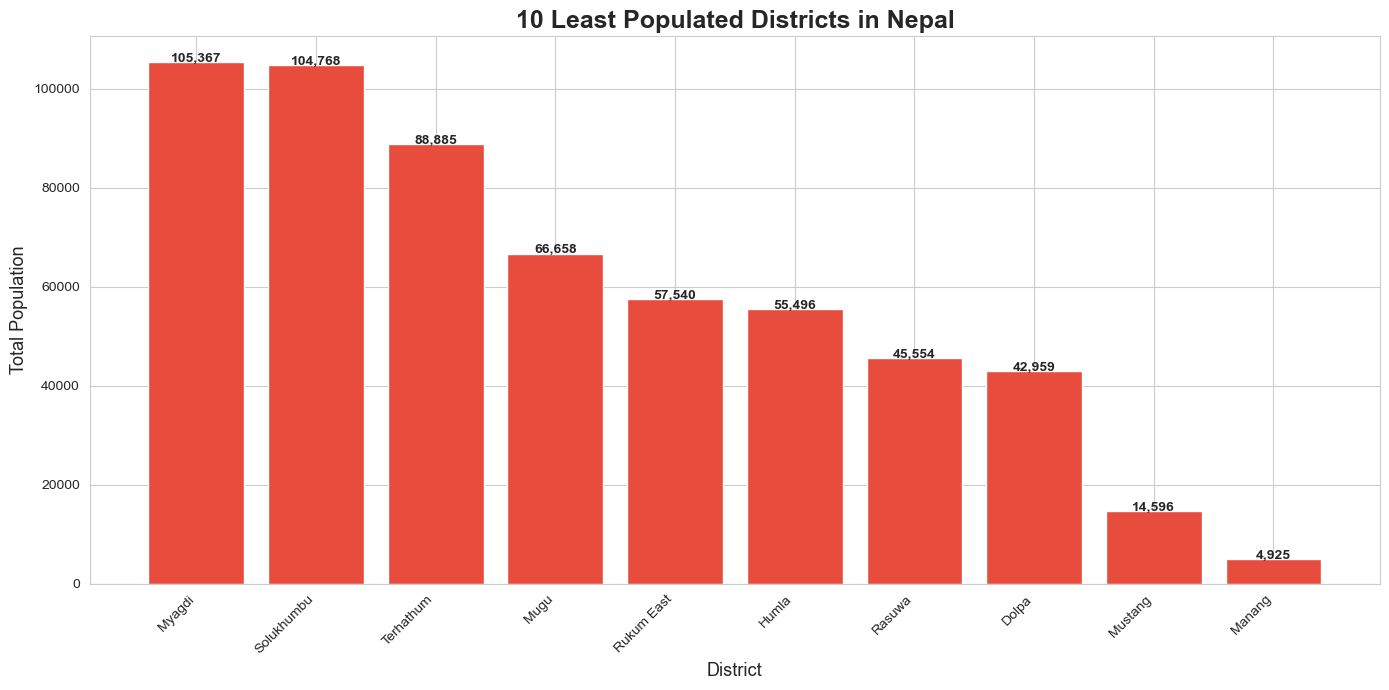

Chart 2 saved!


In [7]:
# Bottom 10 least populated districts
bottom10 = district_pop.tail(10)

plt.figure(figsize=(14, 7))
bars = plt.bar(bottom10.index, bottom10.values, color='#e74c3c')
plt.title('10 Least Populated Districts in Nepal', fontsize=18, fontweight='bold')
plt.xlabel('District', fontsize=13)
plt.ylabel('Total Population', fontsize=13)
plt.xticks(rotation=45, ha='right')

for bar, value in zip(bars, bottom10.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{value:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_bottom10_populated_districts.png', dpi=150)
plt.show()
print("Chart 2 saved!")

## Step 3: Gender Distribution Analysis
Analyzing male vs female population across Nepal.

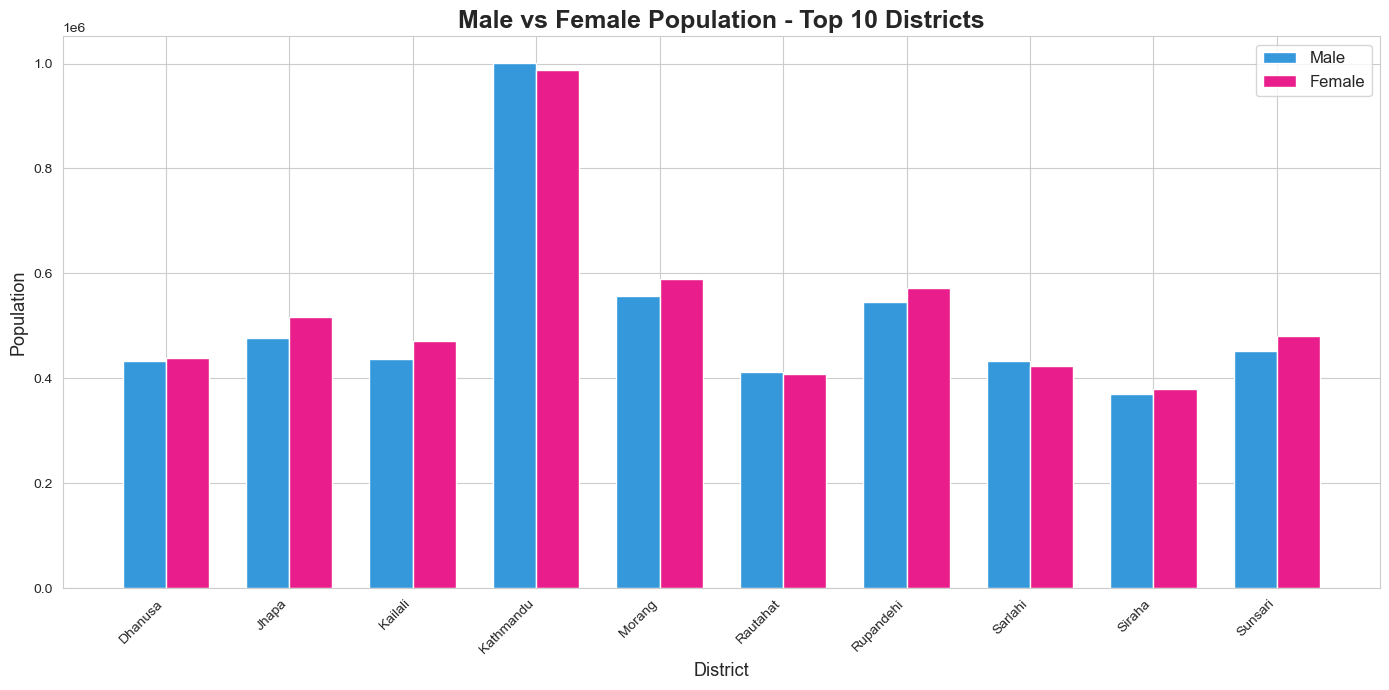

Chart 3 saved!


In [8]:
# Male vs Female population - Top 10 districts
top10_districts = district_pop.head(10).index
df_top10 = df[df['District'].isin(top10_districts)]
gender_data = df_top10.groupby('District')[['Total Male', 'Total Female']].sum()

plt.figure(figsize=(14, 7))
x = range(len(gender_data))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x], gender_data['Total Male'],
                width, label='Male', color='#3498db')
bars2 = plt.bar([i + width/2 for i in x], gender_data['Total Female'],
                width, label='Female', color='#e91e8c')

plt.title('Male vs Female Population - Top 10 Districts', fontsize=18, fontweight='bold')
plt.xlabel('District', fontsize=13)
plt.ylabel('Population', fontsize=13)
plt.xticks(x, gender_data.index, rotation=45, ha='right')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('chart3_gender_distribution.png', dpi=150)
plt.show()
print("Chart 3 saved!")

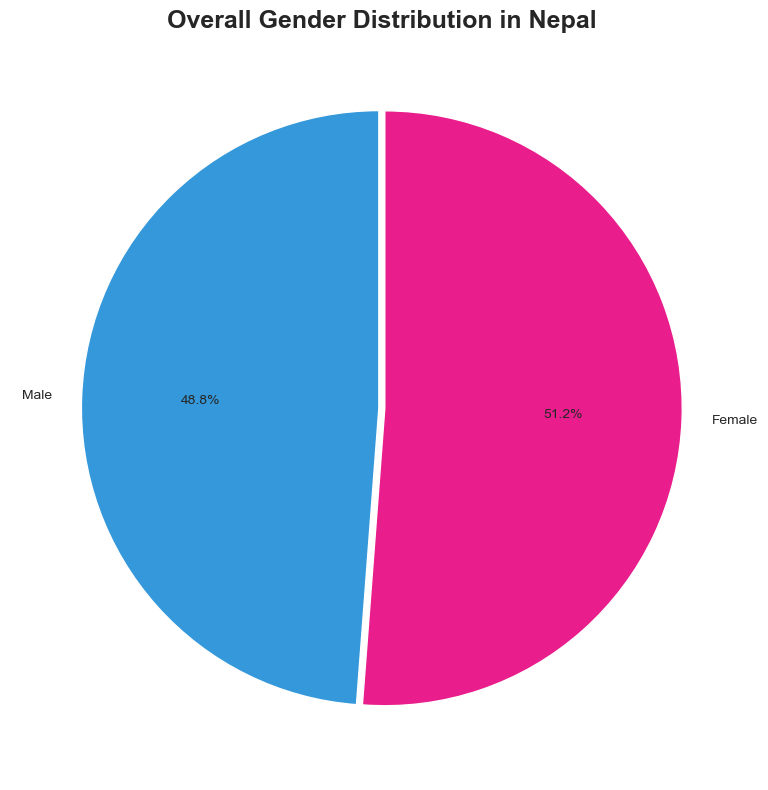

Chart 4 saved!


In [11]:
# Overall Nepal gender distribution pie chart
total_male = df['Total Male'].sum()
total_female = df['Total Female'].sum()

plt.figure(figsize=(8, 8))
plt.pie([total_male, total_female],
        labels=['Male', 'Female'],
        autopct='%1.1f%%',
        colors=['#3498db', '#e91e8c'],
        startangle=90,
        explode=(0.01, 0.01))
plt.title('Overall Gender Distribution in Nepal', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_overall_gender_pie.png', dpi=150)
plt.show()
print("Chart 4 saved!")

## Step 4: Household Analysis
Understanding family and household patterns across Nepal.

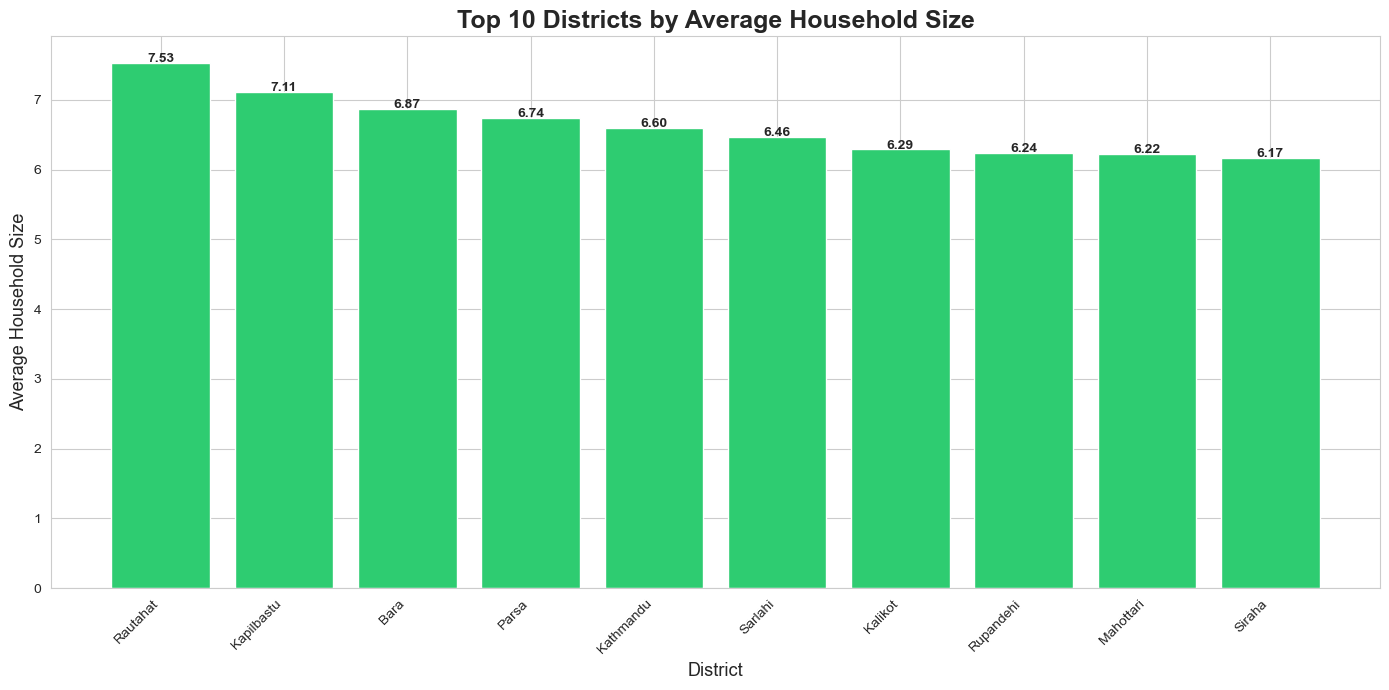

Chart 5 saved!


In [12]:
# Average household size per district
df['Avg Household Size'] = df['Total population'] / df['Total household number']
avg_household = df.groupby('District')['Avg Household Size'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 7))
bars = plt.bar(avg_household.index, avg_household.values, color='#2ecc71')
plt.title('Top 10 Districts by Average Household Size', fontsize=18, fontweight='bold')
plt.xlabel('District', fontsize=13)
plt.ylabel('Average Household Size', fontsize=13)
plt.xticks(rotation=45, ha='right')

for bar, value in zip(bars, avg_household.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_avg_household_size.png', dpi=150)
plt.show()
print("Chart 5 saved!")

## Step 5: Key Insights
Main findings from Nepal Census Population Analysis.

In [13]:
# Calculate all key insights automatically
total_population = df['Total population'].sum()
total_male = df['Total Male'].sum()
total_female = df['Total Female'].sum()
gender_ratio = (total_female / total_male) * 100
most_populated = district_pop.idxmax()
least_populated = district_pop.idxmin()
most_pop_value = district_pop.max()
least_pop_value = district_pop.min()
total_districts = df['District'].nunique()
avg_household_nepal = (df['Total population'].sum() / df['Total household number'].sum())

print("=" * 55)
print("KEY INSIGHTS — NEPAL CENSUS ANALYSIS")
print("=" * 55)
print(f"1. Total Population of Nepal:     {total_population:,}")
print(f"2. Total Male Population:         {total_male:,}")
print(f"3. Total Female Population:       {total_female:,}")
print(f"4. Gender Ratio (F per 100 M):    {gender_ratio:.1f}")
print(f"5. Total Districts Analyzed:      {total_districts}")
print(f"6. Most Populated District:       {most_populated} ({most_pop_value:,})")
print(f"7. Least Populated District:      {least_populated} ({least_pop_value:,})")
print(f"8. Avg Household Size in Nepal:   {avg_household_nepal:.2f} people")
print("=" * 55)

KEY INSIGHTS — NEPAL CENSUS ANALYSIS
1. Total Population of Nepal:     29,074,990
2. Total Male Population:         14,188,639
3. Total Female Population:       14,886,351
4. Gender Ratio (F per 100 M):    104.9
5. Total Districts Analyzed:      77
6. Most Populated District:       Kathmandu (1,988,606)
7. Least Populated District:      Manang (4,925)
8. Avg Household Size in Nepal:   5.15 people


## Conclusion
This analysis of Nepal's census data reveals important demographic 
patterns across all districts. The population is slightly female-dominant
with urban districts like Kathmandu showing significantly higher 
population density compared to rural mountain districts.

In [1]:
import os
print("Files in current directory:")
print(os.listdir('.'))

Files in current directory:
['-1.14-windows.xml', '.anaconda', '.android', '.bash_history', '.BigNox', '.cache', '.conda', '.condarc', '.continuum', '.cursor', '.dia', '.docker', '.git-for-windows-updater', '.gitconfig', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.node_repl_history', '.ssh', '.viminfo', '.VirtualBox', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'census.csv', 'chart1_top10_populated_districts.png', 'chart2_bottom10_populated_districts.png', 'chart3_gender_distribution.png', 'chart4_overall_gender_pie.png', 'chart5_avg_household_size.png', 'Contacts', 'Cookies', 'd4ac4633ebd6440fa397b84f1bc94a3c.7z', 'Desktop', 'Discription.notepad.txt', 'Documents', 'Downloads', 'Favorites', 'form.html', 'helloworld', 'ibisPaint', 'iCloudDrive', 'import javafx.application.java', 'index.html', 'inittk.ini', 'inst.ini', 'IntelGraphicsProfiles', 'lab 1 html', 'Links', 'Local Settings', 'METHODOLOGY.txt', 'Microsoft',